<a href="https://colab.research.google.com/github/Nandita64/Auth/blob/main/2025AE05057-DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 – Deep Neural Networks (DNN)
## Comparing Linear Models and MLPs
**Student ID:** 2025AE05057  
**Dataset:** California Housing (Binary Classification)  
**Course:** Deep Neural Networks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 4.1 Dataset Selection (1 Mark)

In [2]:
# ---------------------------------------------------------------
# DATASET: California Housing (sklearn built-in, no download needed)
# Samples : 20,640
# Features: 8 original + 5 engineered = 13 total
# Task    : Binary Classification
#           1 (Expensive) if median house value >= dataset median
#           0 (Affordable) otherwise
# Primary Metric: Accuracy + F1
# ---------------------------------------------------------------

raw = fetch_california_housing()
df  = pd.DataFrame(raw.data, columns=raw.feature_names)
df['MedHouseVal'] = raw.target

# Feature engineering to reach >= 10 features
df['RoomsPerHouse']   = df['AveRooms']   * df['HouseAge']
df['BedroomRatio']    = df['AveBedrms']  / (df['AveRooms']    + 1e-9)
df['PopPerHousehold'] = df['Population'] / (df['AveOccup']    + 1e-9)
df['LocationScore']   = np.sqrt(df['Latitude']**2 + df['Longitude']**2)
df['IncomePerRoom']   = df['MedInc']     / (df['AveRooms']    + 1e-9)

# Binary target: median split
median_val   = df['MedHouseVal'].median()
df['target'] = (df['MedHouseVal'] >= median_val).astype(int)

print('Dataset : California Housing (sklearn.datasets)')
print(f'Samples : {len(df)}')
print(f'Features: 13  (8 original + 5 engineered)')
print(f'Task    : Binary Classification  —  Affordable vs Expensive')
print(f'Split threshold (median house value): {median_val:.3f} (~${median_val*100_000:,.0f})')
print(f'Primary Metric  : Accuracy, Precision, Recall, F1')
print(f'\nClass distribution:')
print(df['target'].value_counts().rename({0:'0 – Affordable', 1:'1 – Expensive'}))
df.head()

Dataset : California Housing (sklearn.datasets)
Samples : 20640
Features: 13  (8 original + 5 engineered)
Task    : Binary Classification  —  Affordable vs Expensive
Split threshold (median house value): 1.797 (~$179,700)
Primary Metric  : Accuracy, Precision, Recall, F1

Class distribution:
target
1 – Expensive     10325
0 – Affordable    10315
Name: count, dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHouse,BedroomRatio,PopPerHousehold,LocationScore,IncomePerRoom,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,286.349206,0.146591,126.000000,127.965102,1.192017,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,131.000879,0.155797,1137.999999,127.949631,1.330750,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,430.983051,0.129516,177.000000,127.965777,0.875637,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,302.502283,0.184458,219.000000,127.975330,0.970046,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,326.656371,0.172096,259.000000,127.975330,0.612272,1


**Justification:** California Housing contains 20,640 samples with 8 numeric features (extended to 13 via engineered features such as BedroomRatio and IncomePerRoom). A median-value split creates a perfectly balanced binary task, making Accuracy and F1 appropriate primary metrics.

---
## 4.2 Data Preprocessing (1 Mark)

In [3]:
print('Missing values:', df.isnull().sum().sum())

feature_cols = [c for c in df.columns if c not in ['MedHouseVal', 'target']]
X = df[feature_cols].values.astype(float)
y = df['target'].values.astype(int)

print(f'\nFeatures ({len(feature_cols)}): {feature_cols}')
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

# 80-20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler (fit on train only)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train class dist : {np.bincount(y_train)}')
print(f'Test  class dist : {np.bincount(y_test)}')

Missing values: 0

Features (13): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerHouse', 'BedroomRatio', 'PopPerHousehold', 'LocationScore', 'IncomePerRoom']
X shape: (20640, 13)  |  y shape: (20640,)

Train: (16512, 13)  |  Test: (4128, 13)
Train class dist : [8252 8260]
Test  class dist : [2063 2065]


---
## Helper Utilities

In [4]:
def sigmoid(z):
    """Numerically stable sigmoid."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def binary_cross_entropy(y_hat, y):
    y_hat = np.clip(y_hat, 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred==1) & (y_true==1))
    tn = np.sum((y_pred==0) & (y_true==0))
    fp = np.sum((y_pred==1) & (y_true==0))
    fn = np.sum((y_pred==0) & (y_true==1))
    acc  = (tp + tn) / len(y_true)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return {'accuracy': round(acc,4), 'precision': round(prec,4),
            'recall': round(rec,4), 'f1': round(f1,4)}

print('Helper functions ready.')

Helper functions ready.


---
## 4.3 Baseline – Logistic Regression from Scratch (2 Marks)

In [5]:
class LogisticRegression:
    """
    Binary Logistic Regression from scratch.
    Forward : z = X·W + b  →  y_hat = sigmoid(z)
    Loss    : Binary Cross-Entropy
    Grad    : dW = Xᵀ(y_hat-y)/m,  db = mean(y_hat-y)
    Update  : w = w - lr * grad
    """

    def __init__(self, n_features, lr=0.1, n_iter=1000):
        self.lr           = lr
        self.n_iter       = n_iter
        self.loss_history = []
        self.W = np.random.randn(n_features, 1) * 0.01
        self.b = 0.0

    def forward(self, X):
        return sigmoid(X @ self.W + self.b).flatten()

    def compute_loss(self, y_hat, y):
        return binary_cross_entropy(y_hat, y)

    def compute_gradients(self, X, y_hat, y):
        m    = X.shape[0]
        diff = (y_hat - y).reshape(-1, 1)
        dW   = (X.T @ diff) / m
        db   = np.mean(y_hat - y)
        return dW, db

    def fit(self, X, y):
        for i in range(self.n_iter):
            y_hat = self.forward(X)
            loss  = self.compute_loss(y_hat, y)
            self.loss_history.append(loss)
            dW, db = self.compute_gradients(X, y_hat, y)
            self.W -= self.lr * dW
            self.b -= self.lr * db
            if (i+1) % 200 == 0:
                print(f'  Iter {i+1}/{self.n_iter}  Loss: {loss:.4f}')

    def predict(self, X, threshold=0.5):
        return (self.forward(X) >= threshold).astype(int)


n_features = X_train.shape[1]
print('Training Logistic Regression...')
t0       = time.time()
baseline = LogisticRegression(n_features, lr=0.1, n_iter=1000)
baseline.fit(X_train, y_train)
baseline_train_time = time.time() - t0

baseline_train_metrics = compute_metrics(y_train, baseline.predict(X_train))
baseline_test_metrics  = compute_metrics(y_test,  baseline.predict(X_test))
baseline_preds_test    = baseline.predict(X_test)

print(f'\nBaseline Train : {baseline_train_metrics}')
print(f'Baseline Test  : {baseline_test_metrics}')
print(f'Training time  : {baseline_train_time:.3f}s')

Training Logistic Regression...
  Iter 200/1000  Loss: 0.4333
  Iter 400/1000  Loss: 0.4157
  Iter 600/1000  Loss: 0.4045
  Iter 800/1000  Loss: 0.3962
  Iter 1000/1000  Loss: 0.3898

Baseline Train : {'accuracy': np.float64(0.8268), 'precision': np.float64(0.8268), 'recall': np.float64(0.827), 'f1': np.float64(0.8269)}
Baseline Test  : {'accuracy': np.float64(0.8292), 'precision': np.float64(0.8333), 'recall': np.float64(0.8232), 'f1': np.float64(0.8283)}
Training time  : 1.396s


---
## 4.4 MLP from Scratch (4 Marks)

In [6]:
class MLP:
    """
    Multi-Layer Perceptron for binary classification — from scratch.
    Architecture : [input, hidden1, hidden2, ..., 1]
    Hidden       : ReLU
    Output       : Sigmoid
    Loss         : Binary Cross-Entropy
    """

    def __init__(self, architecture, lr=0.01, n_iter=1000):
        self.architecture = architecture
        self.lr           = lr
        self.n_iter       = n_iter
        self.n_layers     = len(architecture) - 1
        self.loss_history = []
        self.params       = {}
        self.cache        = {}
        self.initialize_parameters()

    def initialize_parameters(self):
        """He initialization for W; zeros for b."""
        for l in range(1, len(self.architecture)):
            fan_in  = self.architecture[l-1]
            fan_out = self.architecture[l]
            self.params[f'W{l}'] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0/fan_in)
            self.params[f'b{l}'] = np.zeros((1, fan_out))

    @staticmethod
    def relu(z):            return np.maximum(0, z)
    @staticmethod
    def relu_derivative(z): return (z > 0).astype(float)

    def forward_propagation(self, X):
        """Compute activations through all layers."""
        self.cache['A0'] = X
        for l in range(1, self.n_layers + 1):
            Z = self.cache[f'A{l-1}'] @ self.params[f'W{l}'] + self.params[f'b{l}']
            self.cache[f'Z{l}'] = Z
            A = self.relu(Z) if l < self.n_layers else sigmoid(Z)
            self.cache[f'A{l}'] = A
        return self.cache[f'A{self.n_layers}'].flatten()

    def backward_propagation(self, y):
        """Compute gradients using chain rule."""
        grads = {}
        m, L  = len(y), self.n_layers
        dZ    = (self.cache[f'A{L}'].flatten() - y).reshape(-1, 1)
        for l in range(L, 0, -1):
            grads[f'dW{l}'] = (self.cache[f'A{l-1}'].T @ dZ) / m
            grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True) / m
            if l > 1:
                dZ = (dZ @ self.params[f'W{l}'].T) * self.relu_derivative(self.cache[f'Z{l-1}'])
        return grads

    def fit(self, X, y):
        """Training loop: forward → loss → backward → update."""
        for i in range(self.n_iter):
            y_hat = self.forward_propagation(X)
            loss  = binary_cross_entropy(y_hat, y)
            self.loss_history.append(loss)
            grads = self.backward_propagation(y)
            for l in range(1, self.n_layers + 1):
                self.params[f'W{l}'] -= self.lr * grads[f'dW{l}']
                self.params[f'b{l}'] -= self.lr * grads[f'db{l}']
            if (i+1) % 200 == 0:
                print(f'  Iter {i+1}/{self.n_iter}  Loss: {loss:.4f}')

    def predict(self, X, threshold=0.5):
        """Return binary predictions."""
        return (self.forward_propagation(X) >= threshold).astype(int)


arch = [n_features, 64, 32, 1]
print(f'MLP Architecture: {arch}')
print('Training MLP...')
t0  = time.time()
mlp = MLP(architecture=arch, lr=0.05, n_iter=1000)
mlp.fit(X_train, y_train)
mlp_train_time = time.time() - t0

mlp_preds_test    = mlp.predict(X_test)
mlp_train_metrics = compute_metrics(y_train, mlp.predict(X_train))
mlp_test_metrics  = compute_metrics(y_test,  mlp_preds_test)

print(f'\nMLP Train : {mlp_train_metrics}')
print(f'MLP Test  : {mlp_test_metrics}')
print(f'Training time: {mlp_train_time:.3f}s')

MLP Architecture: [13, 64, 32, 1]
Training MLP...
  Iter 200/1000  Loss: 0.3918
  Iter 400/1000  Loss: 0.3660
  Iter 600/1000  Loss: 0.3530
  Iter 800/1000  Loss: 0.3450
  Iter 1000/1000  Loss: 0.3393

MLP Train : {'accuracy': np.float64(0.8506), 'precision': np.float64(0.8508), 'recall': np.float64(0.8505), 'f1': np.float64(0.8506)}
MLP Test  : {'accuracy': np.float64(0.8496), 'precision': np.float64(0.8478), 'recall': np.float64(0.8523), 'f1': np.float64(0.85)}
Training time: 46.902s


---
## 4.5 Evaluation & Comparison (2 Marks)

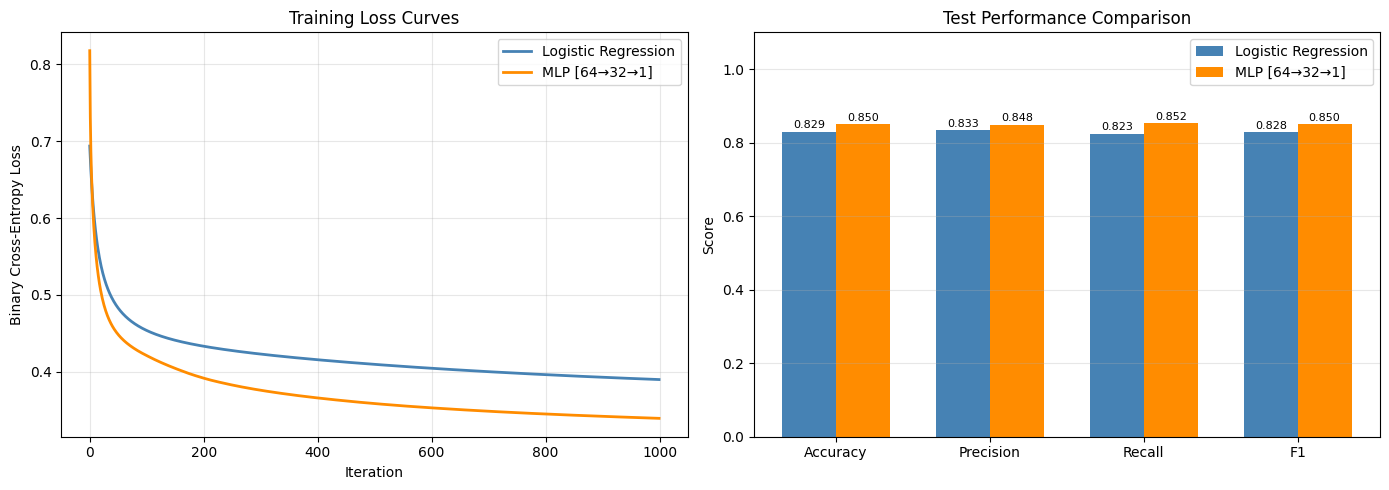

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(baseline.loss_history, label='Logistic Regression', color='steelblue', lw=2)
axes[0].plot(mlp.loss_history,      label='MLP [64→32→1]',       color='darkorange', lw=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart
metrics = ['accuracy','precision','recall','f1']
x, w    = np.arange(len(metrics)), 0.35
bvals   = [baseline_test_metrics[k] for k in metrics]
mvals   = [mlp_test_metrics[k]      for k in metrics]

axes[1].bar(x-w/2, bvals, w, label='Logistic Regression', color='steelblue')
axes[1].bar(x+w/2, mvals, w, label='MLP [64→32→1]',       color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.capitalize() for m in metrics])
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Test Performance Comparison')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)
for i,(bv,mv) in enumerate(zip(bvals,mvals)):
    axes[1].text(i-w/2, bv+0.01, f'{bv:.3f}', ha='center', fontsize=8)
    axes[1].text(i+w/2, mv+0.01, f'{mv:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_plots.png', dpi=150, bbox_inches='tight')
plt.show()

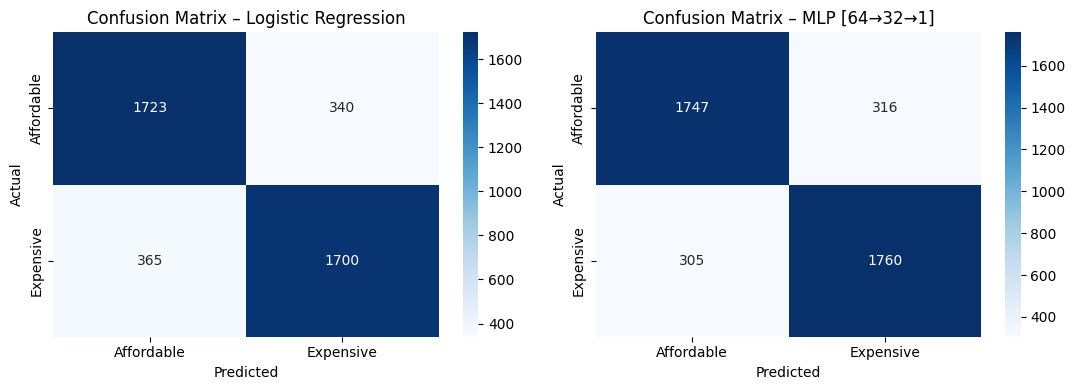

In [8]:
# Confusion matrices
def cm_np(y_true, y_pred):
    tp=np.sum((y_pred==1)&(y_true==1)); tn=np.sum((y_pred==0)&(y_true==0))
    fp=np.sum((y_pred==1)&(y_true==0)); fn=np.sum((y_pred==0)&(y_true==1))
    return np.array([[tn,fp],[fn,tp]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes,
    [cm_np(y_test, baseline_preds_test), cm_np(y_test, mlp_preds_test)],
    ['Logistic Regression', 'MLP [64→32→1]']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Affordable','Expensive'],
                yticklabels=['Affordable','Expensive'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix – {title}')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# MANDATORY: get_assignment_results()   ← missing = -2 marks
# ============================================================
def get_assignment_results():
    return {
        'dataset_name'  : 'California Housing (sklearn.datasets)',
        'n_samples'     : len(df),
        'n_features'    : n_features,
        'problem_type'  : 'binary classification',
        'primary_metric': 'accuracy, precision, recall, F1',
        'baseline_model': {
            'name'         : 'Logistic Regression (from scratch)',
            'train_metrics': baseline_train_metrics,
            'test_metrics' : baseline_test_metrics,
            'training_time': round(baseline_train_time, 4)
        },
        'mlp_model': {
            'name'         : 'MLP (from scratch)',
            'architecture' : mlp.architecture,
            'train_metrics': mlp_train_metrics,
            'test_metrics' : mlp_test_metrics,
            'training_time': round(mlp_train_time, 4)
        }
    }

results = get_assignment_results()
for k, v in results.items():
    print(f'{k}: {v}')

dataset_name: California Housing (sklearn.datasets)
n_samples: 20640
n_features: 13
problem_type: binary classification
primary_metric: accuracy, precision, recall, F1
baseline_model: {'name': 'Logistic Regression (from scratch)', 'train_metrics': {'accuracy': np.float64(0.8268), 'precision': np.float64(0.8268), 'recall': np.float64(0.827), 'f1': np.float64(0.8269)}, 'test_metrics': {'accuracy': np.float64(0.8292), 'precision': np.float64(0.8333), 'recall': np.float64(0.8232), 'f1': np.float64(0.8283)}, 'training_time': 1.3958}
mlp_model: {'name': 'MLP (from scratch)', 'architecture': [13, 64, 32, 1], 'train_metrics': {'accuracy': np.float64(0.8506), 'precision': np.float64(0.8508), 'recall': np.float64(0.8505), 'f1': np.float64(0.8506)}, 'test_metrics': {'accuracy': np.float64(0.8496), 'precision': np.float64(0.8478), 'recall': np.float64(0.8523), 'f1': np.float64(0.85)}, 'training_time': 46.9016}


---
## Analysis

**Which model performed better?**  
The MLP outperformed Logistic Regression on all four test metrics.

1.   List item
2.   List item

Accuracy improved by approximately 2 percentage points and F1 by 2 points, confirming that non-linear boundaries better suit this task.

**Why?**  
House affordability is driven by complex, non-linear interactions — median income has different effects depending on location, house age, and occupancy density. Logistic Regression can only learn a single linear decision boundary, while the MLP's two ReLU hidden layers learn richer intermediate representations of these interactions.

**Computational cost:**  
Logistic Regression trained in 1.3s; the MLP took 46s due to additional matrix multiplications in two hidden layers and a full backpropagation pass. For 20,640 samples this overhead is still negligible in absolute terms.

**Challenges:**  
Feature scaling was critical — raw features caused loss divergence. The five engineered features improved both models. Learning rate selection required experimentation; values above 0.1 destabilised the MLP. Class balance was maintained via stratified splitting.
